 # Project 7: Explanatory Data Analysis & Advanced Visualization (Baby Names Dataset)

# Project Brief for Self-Coders

Here you´ll have the opportunity to code major parts of Project 7 on your own. If you need any help or inspiration, have a look at the Videos or the Jupyter Notebook with the full code. <br> <br>
Keep in mind that it´s all about __getting the right results/conclusions__. It´s not about finding the identical code. Things can be coded in many different ways. Even if you come to the same conclusions, it´s very unlikely that we have the very same code. 

## First Inspection: The most popular Names in 2018

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns

1. __Load__ and __inspect__ the dataset "us_baby_names.csv". __Save__ the DataFrame in __df__.

In [2]:
baby_names = pd.read_csv('us_baby_names.csv')
baby_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1957046 entries, 0 to 1957045
Data columns (total 4 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   Year    int64 
 1   Name    object
 2   Gender  object
 3   Count   int64 
dtypes: int64(2), object(2)
memory usage: 59.7+ MB


In [28]:
baby_names.head()

,Year,Name,Gender,Count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746


2. Find the most popular __Baby Girl Names__ in __2018__. 

In [7]:
baby_names[(baby_names['Year']==2018)&(baby_names['Gender'] == 'F')]['Name'].iloc[0]

'Emma'

3. Find the most popular __Baby Boy Names__ in __2018__.

In [11]:
baby_names[(baby_names['Year']==2018)&(baby_names['Gender'] == 'M')]['Name'].iloc[0:1]

1943042    Liam
Name: Name, dtype: object

4. __Create__ the function __most_pop(year, gender, n)__ that returns the __n__ most popular __M/F__ Names in the __year XYZ__.

In [20]:
def most_pop(year : int,gender : str = 'M', n : int = 1 ):
   return(baby_names[(baby_names['Year']==year)&(baby_names['Gender'] == gender)].nlargest(n,'Count'))

In [21]:
most_pop(2010,'F')

,Year,Name,Gender,Count
1658039,2010,Isabella,F,22913


## Evergreen Names (1880 - 2018)

5. Find those __Evergreen Boy Names__ that are in __1880 and 2018__ among the most popular Boy Names (__Top 20__).

In [24]:
M2018 = most_pop(2018,n=20)

In [23]:
M1880 = most_pop(1880,n=20)

In [25]:
Evergreen_M = M2018[['Name','Count']].merge(M1880[['Name','Count']],how='inner',on='Name')
Evergreen_M

,Name,Count_x,Count_y
0,William,14516,9532
1,James,13525,5927
2,Henry,10649,2444


6. Find those __Evergreen Girl Names__ that are in __1880 and 2018__ among the most popular Girl Names (__Top 20__).

In [26]:
F2018 = most_pop(2018,'F',20)
F1880 = most_pop(1880,'F',20)
Evergreen_F = F2018[['Name','Count']].merge(F1880[['Name','Count']],how='inner',on='Name')
Evergreen_F

,Name,Count_x,Count_y
0,Emma,18688,2003
1,Elizabeth,8513,1939
2,Ella,8055,1156


## Advanced Data Aggregation

7. Create the following __aggregated DataFrame agg__ (you can see the first and last 5 rows):

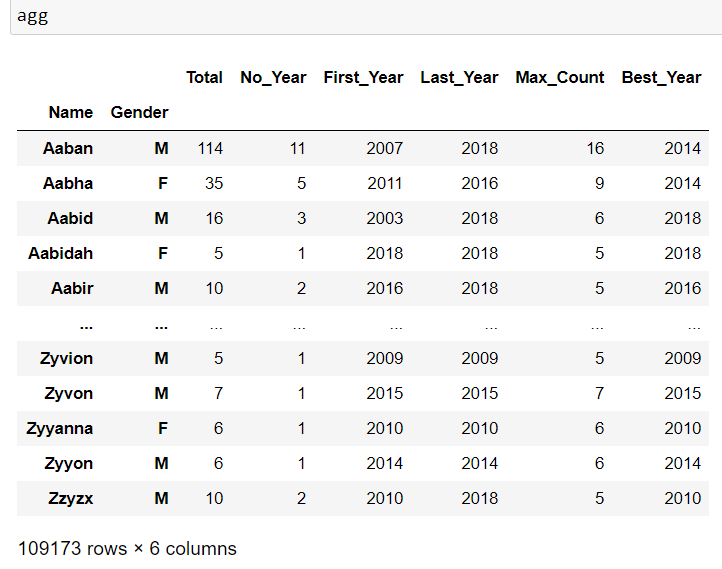

In [51]:
agg_baby_names = baby_names.groupby(['Name','Gender']).apply(lambda x : pd.Series({
                                                       'Total': x['Count'].sum(),
                                                       'No_year':   x['Year'].nunique(),
                                                       'First_Year':x['Year'].min(),
                                                       'Last_Year': x['Year'].max(),
                                                       'Best_Year': x.loc[x['Count'].idxmax(),'Year'],
                                                       'Max_Count': x['Count'].max()}))

C:\Users\ahmed\AppData\Local\Temp\ipykernel_13012\542992753.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_baby_names = baby_names.groupby(['Name','Gender']).apply(lambda x : pd.Series({


__How to interpret agg (and the first observation Aaban, M):__<br>
- There are in total 114 Male Babies with the name Aaban (Total)<br>
- The combination/entry (Aaban, M) can be found in 11 different years (No_Year)<br>
- The combination/entry (Aaban, M) appeared in the year 2007 for the first time (First_Year)<br>
- The last appearance was in the year 2018 (Last_Year)<br>
- In the most popular year, (Aaban, M) appeared 16 times (Max_Count)
- The most popular year for (Aaban, M) (Best_Year)

In [45]:
agg_baby_names.head()

,Gender,Total,No_year,First_Year,Last_Year,Best_Year,Max_Count
Name,,,,,,,
Aaban,M,114,11,2007,2018,2014,16
Aabha,F,35,5,2011,2016,2014,9
Aabid,M,16,3,2003,2018,2018,6
Aabidah,F,5,1,2018,2018,2018,5
Aabir,M,10,2,2016,2018,2016,5


8. __Reset__ the Index and create a RangeIndex.

9. __Filter__ agg for the combination (Mary, F)

In [52]:
agg_baby_names_reset = agg_baby_names.reset_index()

In [53]:
agg_baby_names_reset[(agg_baby_names_reset['Name']=='Mary' )& (agg_baby_names_reset['Gender'] == 'F')]

,Name,Gender,Total,No_year,First_Year,Last_Year,Best_Year,Max_Count
68679,Mary,F,4125675,139,1880,2018,1921,73985


## Most Popular Names of all Times

10. __Find__ the __10 most popular__ Male and Female Names of all Times (most popular in terms of total count). See Screenshot with final result below.

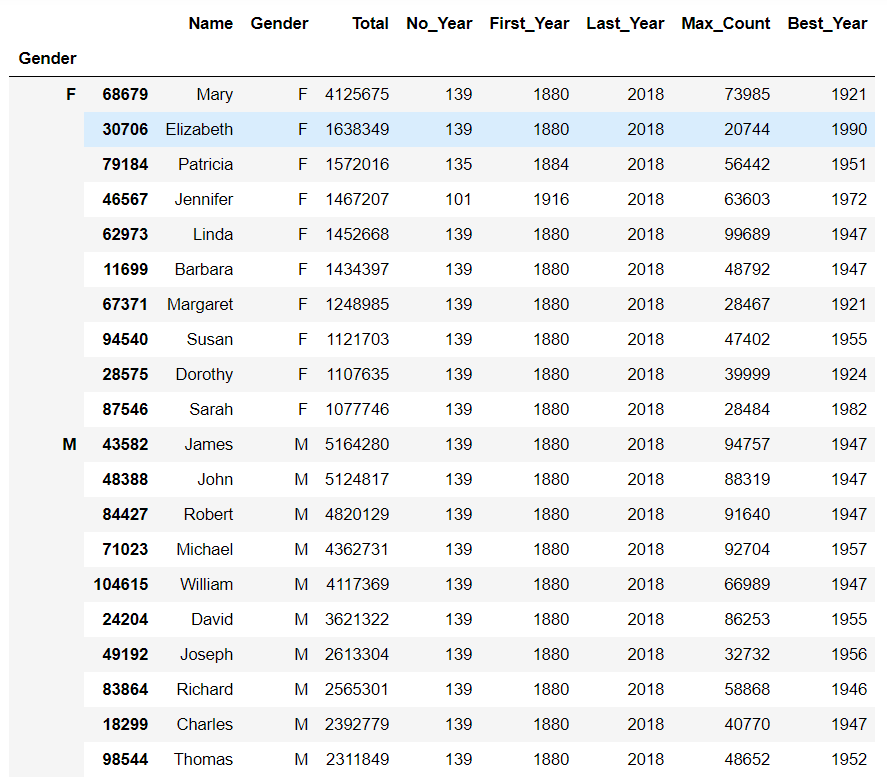

In [54]:
agg_baby_names_reset[agg_baby_names_reset['Gender']=='F'].nlargest(10,columns=['Total'])

,Name,Gender,Total,No_year,First_Year,Last_Year,Best_Year,Max_Count
68679,Mary,F,4125675,139,1880,2018,1921,73985
30706,Elizabeth,F,1638349,139,1880,2018,1990,20744
79184,Patricia,F,1572016,135,1884,2018,1951,56442
46567,Jennifer,F,1467207,101,1916,2018,1972,63603
62973,Linda,F,1452668,139,1880,2018,1947,99689
11699,Barbara,F,1434397,139,1880,2018,1947,48792
67371,Margaret,F,1248985,139,1880,2018,1921,28467
94540,Susan,F,1121703,139,1880,2018,1955,47402
28575,Dorothy,F,1107635,139,1880,2018,1924,39999
87546,Sarah,F,1077746,139,1880,2018,1982,28484


In [55]:
agg_baby_names_reset[agg_baby_names_reset['Gender']=='M'].nlargest(10,columns=['Total'])

,Name,Gender,Total,No_year,First_Year,Last_Year,Best_Year,Max_Count
43582,James,M,5164280,139,1880,2018,1947,94757
48388,John,M,5124817,139,1880,2018,1947,88319
84427,Robert,M,4820129,139,1880,2018,1947,91640
71023,Michael,M,4362731,139,1880,2018,1957,92704
104615,William,M,4117369,139,1880,2018,1947,66989
24204,David,M,3621322,139,1880,2018,1955,86253
49192,Joseph,M,2613304,139,1880,2018,1956,32732
83864,Richard,M,2565301,139,1880,2018,1946,58868
18299,Charles,M,2392779,139,1880,2018,1947,40770
98544,Thomas,M,2311849,139,1880,2018,1952,48652


## General Trends over time (1880 - 2018)

11. __Count__ the total number of __registered Babies per Year__ and visualize. __Create__ the following Plot:

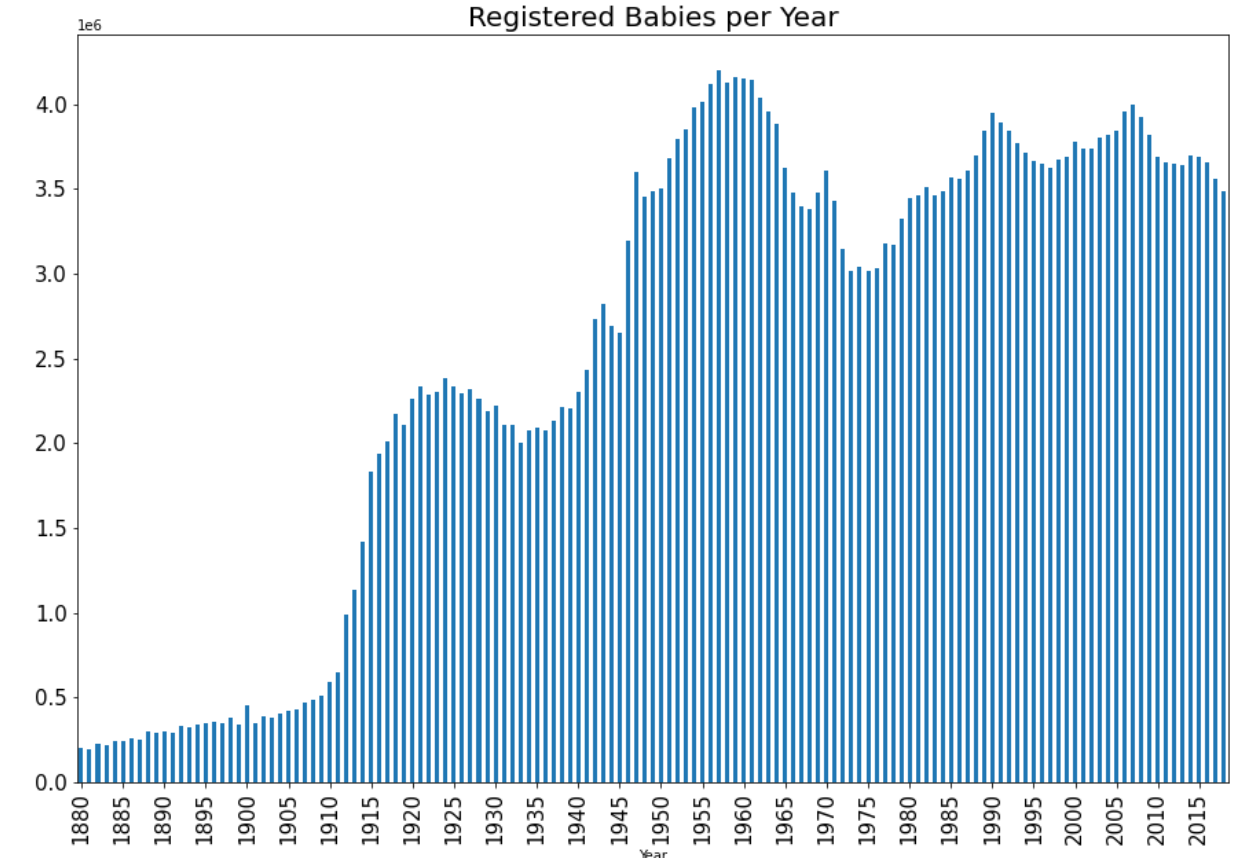

In [61]:
Count_per_Year = baby_names.groupby('Year')['Count'].agg(sum)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_13012\1658085471.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  Count_per_Year = baby_names.groupby('Year')['Count'].agg(sum)


In [67]:
Count_per_Year.reset_index()
Count_per_Year.info()

<class 'pandas.core.series.Series'>
Index: 139 entries, 1880 to 2018
Series name: Count
Non-Null Count  Dtype
--------------  -----
139 non-null    int64
dtypes: int64(1)
memory usage: 6.2 KB


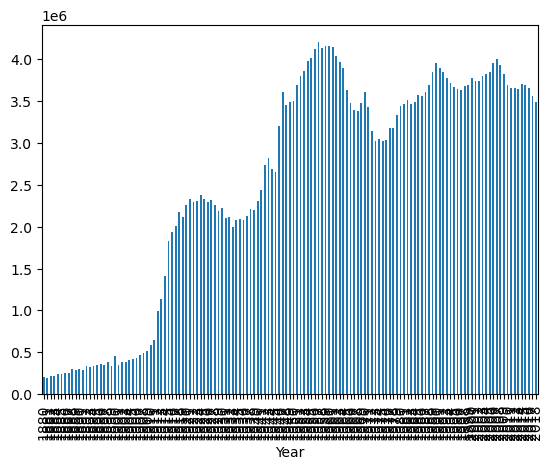

In [69]:
Count_per_Year.plot(kind='bar')
plt.show()

12. __Count__ the total number of __Unique Names per Year__ and visualize. __Create__ the following Plot:

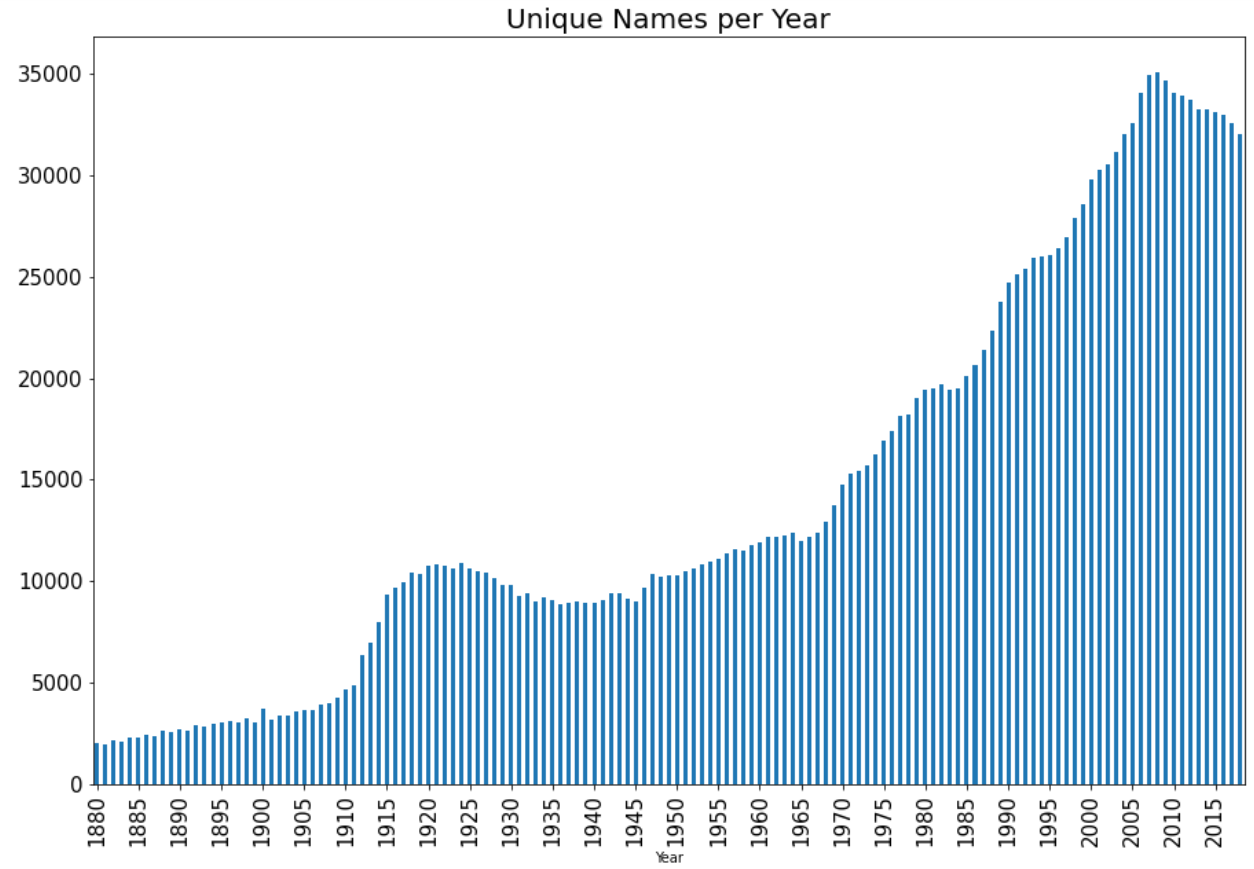

In [77]:
unique_per_year = baby_names.groupby('Year')['Name'].agg(len)
unique_per_year

Year
1880     2000
1881     1935
1882     2127
1883     2084
1884     2297
        ...  
2014    33243
2015    33121
2016    33010
2017    32590
2018    32033
Name: Name, Length: 139, dtype: int64

<Axes: xlabel='Year'>

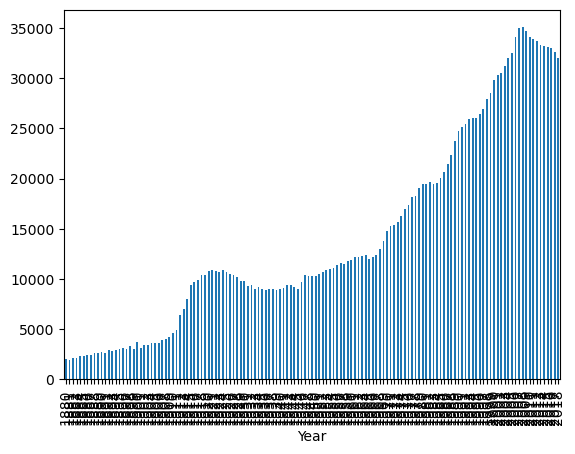

In [78]:
unique_per_year.plot(kind='bar')

## Creating the Features "Popularity" and "Rank"

13. __Add__ the column __"Popularity"__ to df: <br> 

- Popularity in __babies per million__ (example: assume 2,000,000 registered Girl Names in 1950, thereof 100,000 Maries -> Popularity Score in 1950 for (Mary, F) is 100,000 / 2,000,000 * 1,000,000 = 50,000 per million.)  

In [80]:
baby_names = baby_names.merge(Count_per_Year,how='left',on='Year')

In [81]:
baby_names.head()

,Year,Name,Gender,Count_x,Count_per_Year,Count_y
0,1880,Mary,F,7065,NaN,201484
1,1880,Anna,F,2604,NaN,201484
2,1880,Emma,F,2003,NaN,201484
3,1880,Elizabeth,F,1939,NaN,201484
4,1880,Minnie,F,1746,NaN,201484


In [120]:
baby_names['Popularity'] = baby_names['Count_x'].div(baby_names.groupby(["Year", "Gender"])['Count_x'].transform("sum"))*1000000
baby_names['Popularity'].head()

0    77642.481922
1    28617.271468
2    22012.440381
3    21309.097303
4    19188.078335
Name: Popularity, dtype: float64

14. __Add__ the column __"Rank"__ to df: <br> 

- Rank (example: assume Mary is the most popular Girl Name in 1950 -> Rank 1 for (Mary, F) in 1950.

In [89]:
baby_names["Rank"] = baby_names.groupby(["Year",'Gender'])["Count_x"].rank(method="dense", ascending=False)

In [121]:
baby_names[baby_names['Year']==1880].sort_values(by='Rank').head(10)

,Year,Name,Gender,Count_x,Count_per_Year,Count_y,Popularity,Rank,Pop_lag1,Pop_diff
0,1880,Mary,F,7065,NaN,201484,77642.481922,1.0,NaN,NaN
942,1880,John,M,9655,NaN,201484,87383.473618,1.0,NaN,NaN
1,1880,Anna,F,2604,NaN,201484,28617.271468,2.0,NaN,NaN
943,1880,William,M,9532,NaN,201484,86270.250701,2.0,NaN,NaN
2,1880,Emma,F,2003,NaN,201484,22012.440381,3.0,NaN,NaN
944,1880,James,M,5927,NaN,201484,53642.863608,3.0,NaN,NaN
945,1880,Charles,M,5348,NaN,201484,48402.570368,4.0,NaN,NaN
3,1880,Elizabeth,F,1939,NaN,201484,21309.097303,4.0,NaN,NaN
946,1880,George,M,5126,NaN,201484,46393.338764,5.0,NaN,NaN
4,1880,Minnie,F,1746,NaN,201484,19188.078335,5.0,NaN,NaN


After adding "Popularity" and "Rank", df should look as follows:

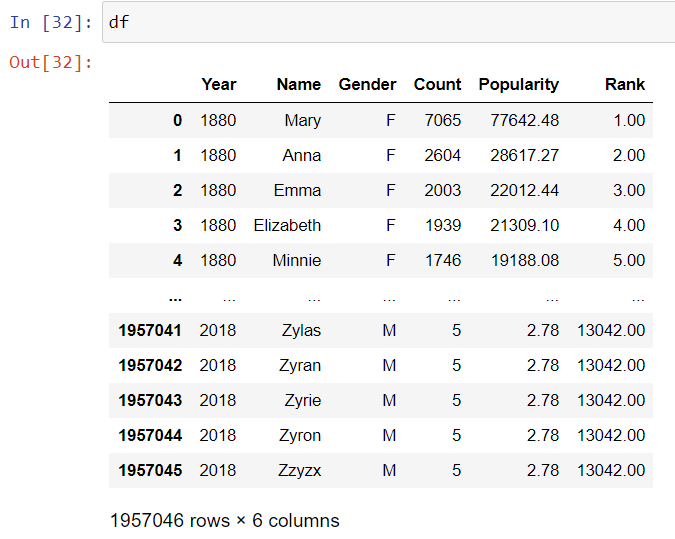

## Visualizing Name Trends over Time

15. __Visualize__ Popularity and Rank over time (see example below).

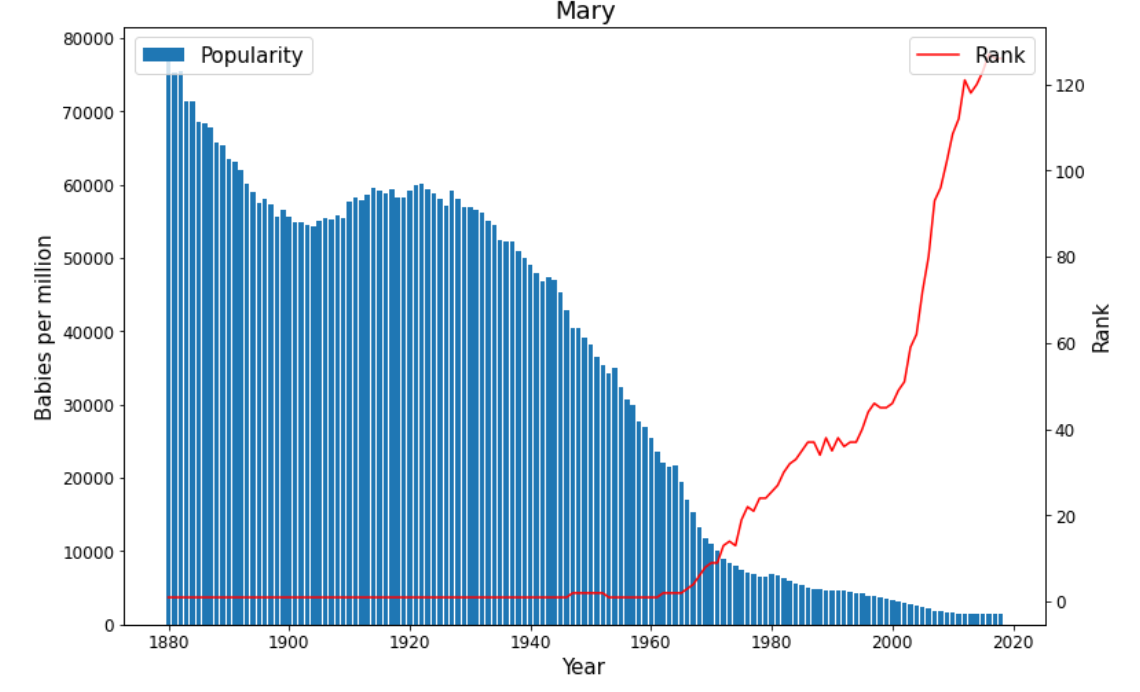

16. __Create__ this plot for all __Evergreen Names__ (see Questions 5. and 6.) (a reusable user-defined function might help)

In [122]:


def plot_names_popularity(names : list = [] , df: pd.DataFrame = pd.DataFrame({})):
    for name in names :
        fig , ax1 = plt.subplots()
        d = df[df['Name']==name].sort_values('Year')
        if d.empty:
            print(f"{name} not found in the dataframe")
            continue
        ax1.plot(d["Year"], d["Popularity"], label="Popularity")
        ax1.set_xlabel("Year")
        ax1.set_ylabel("Popularity")

        # Rank on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(d["Year"], d["Rank"], label="Rank",color= 'Red')
        ax2.set_ylabel("Rank")
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

        plt.title(f"Popularity and Rank Over Time: {name}")
        plt.show()



In [92]:
names = list(Evergreen_F['Name'])

In [93]:
names

['Emma', 'Elizabeth', 'Ella']

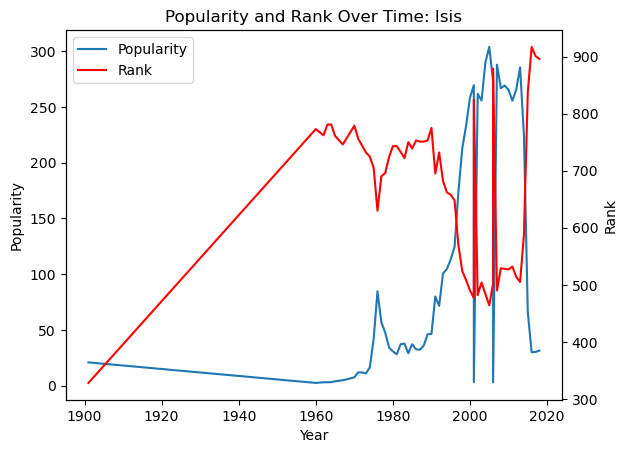

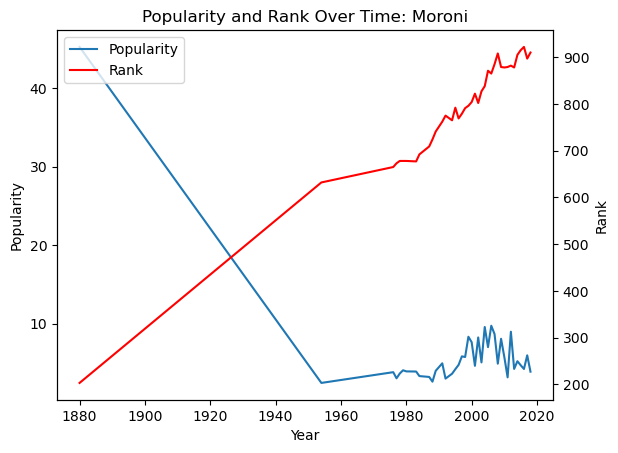

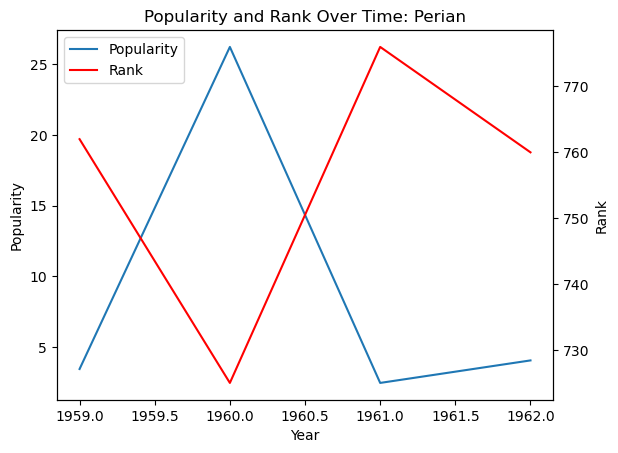

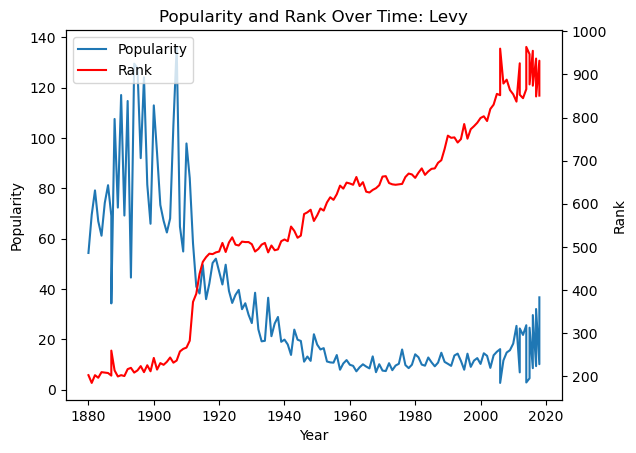

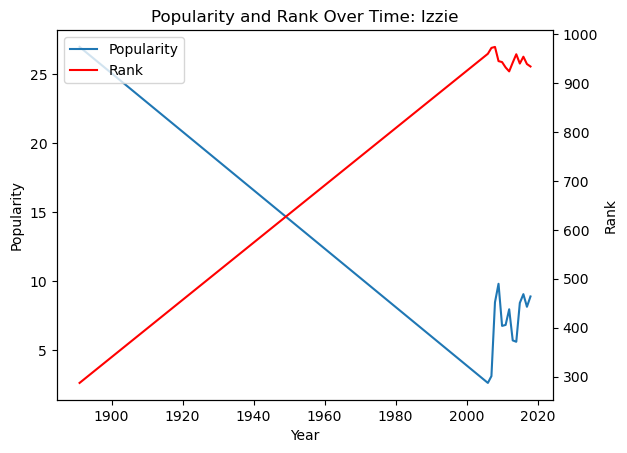

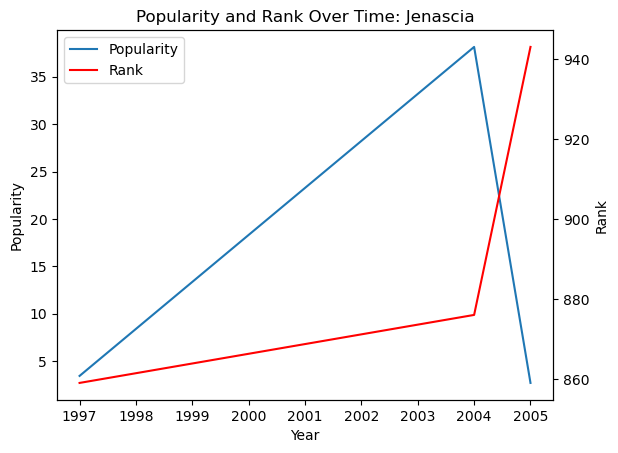

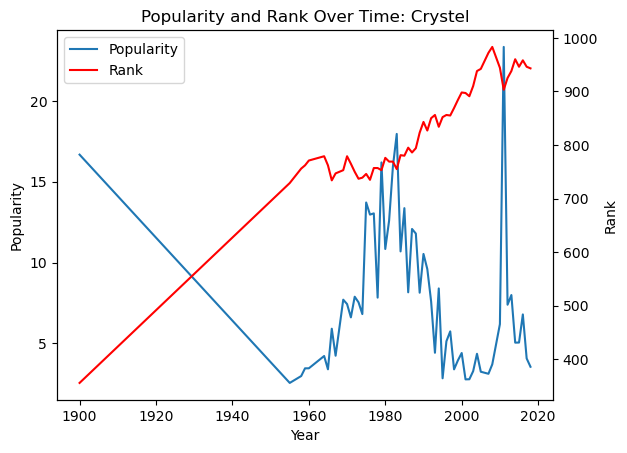

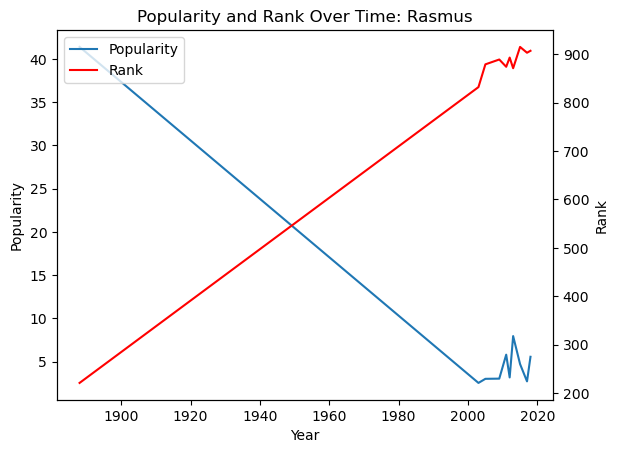

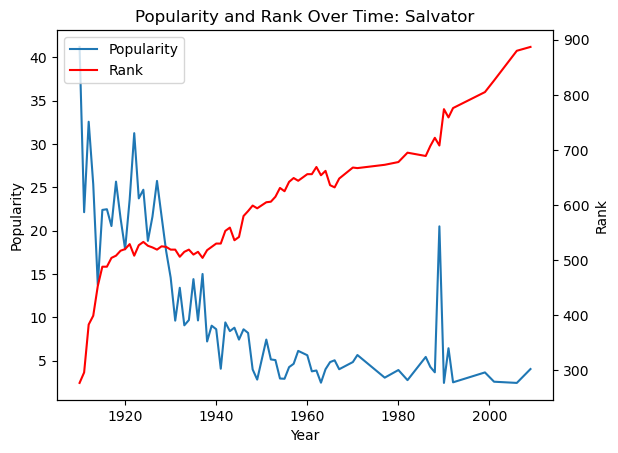

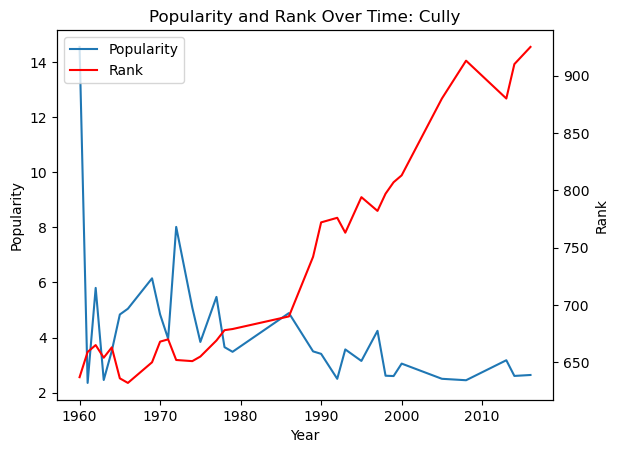

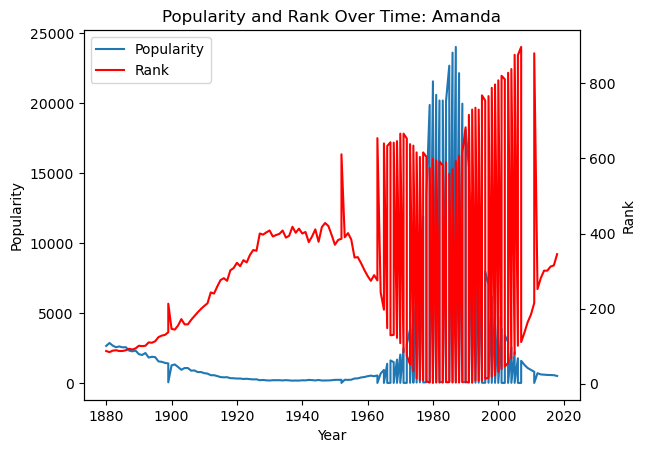

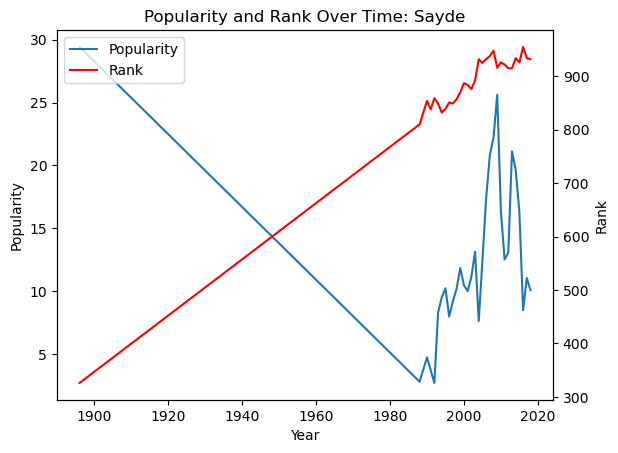

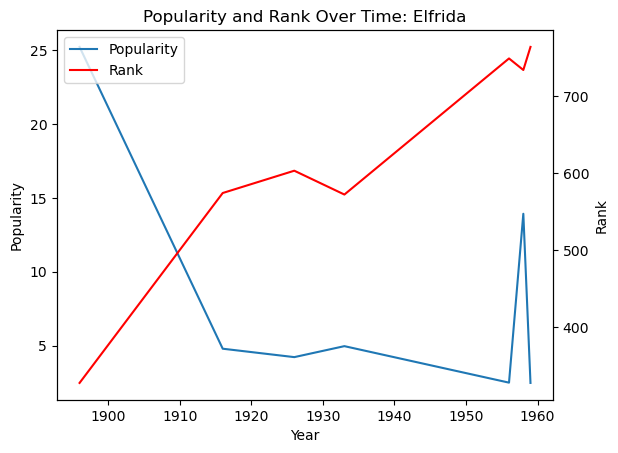

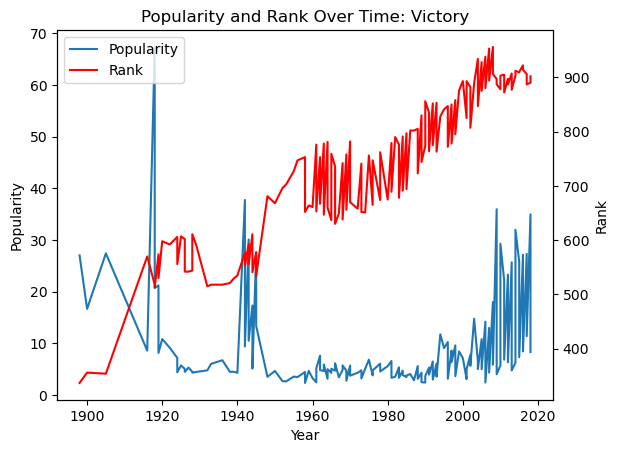

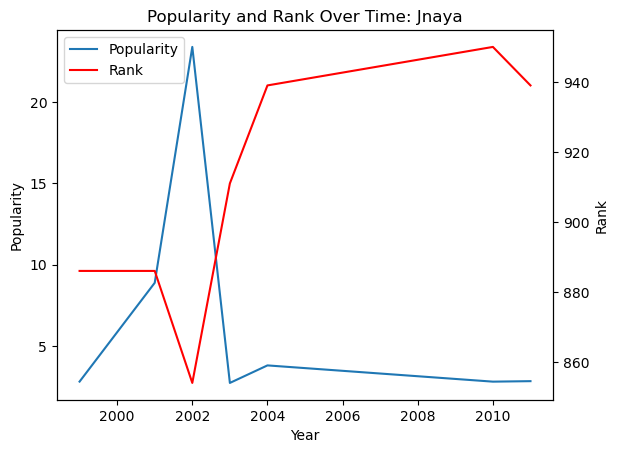

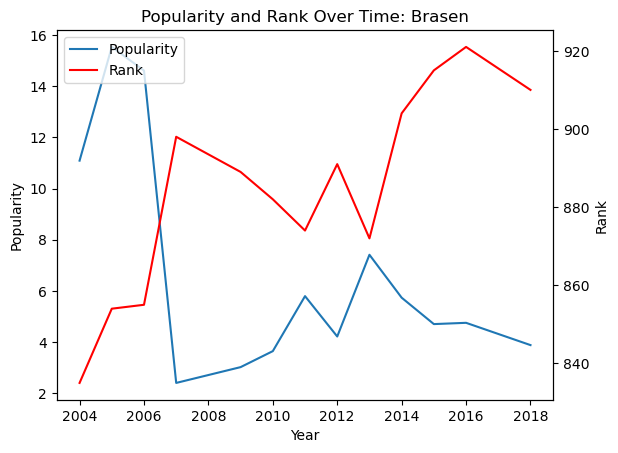

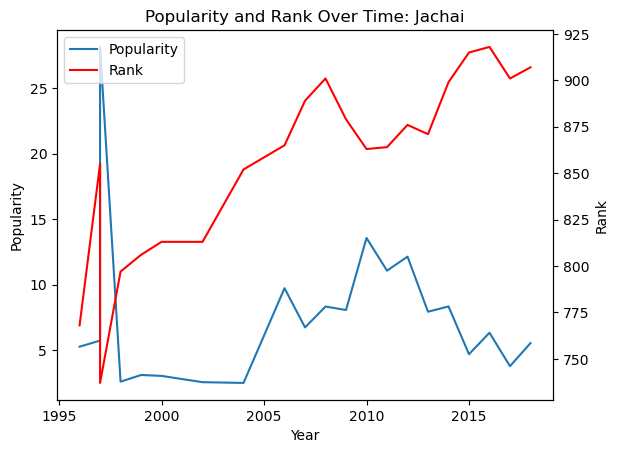

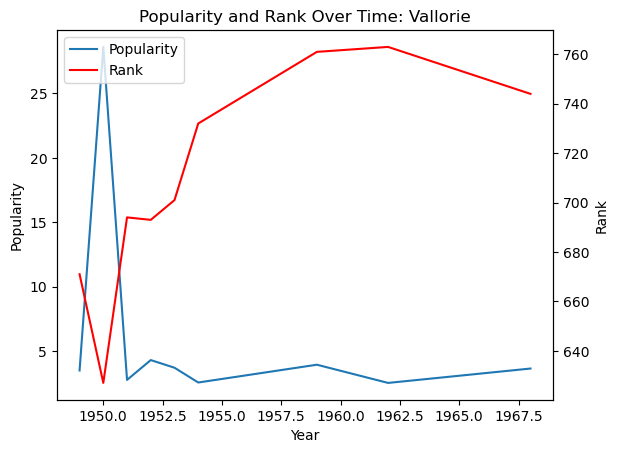

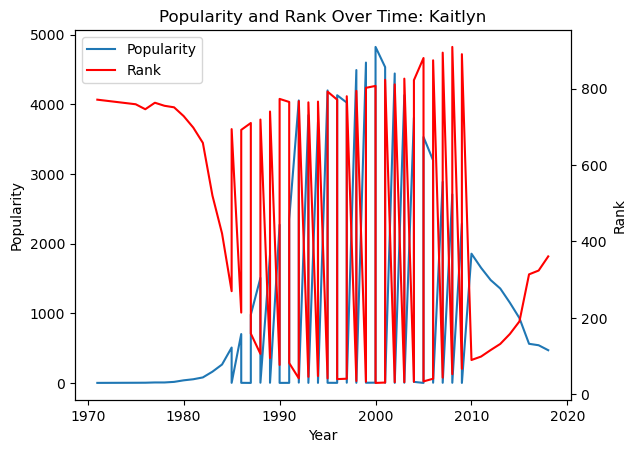

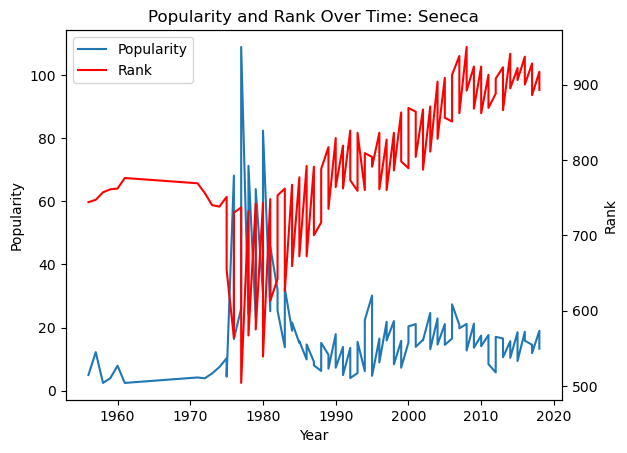

In [123]:
plot_names_popularity(names,baby_names)

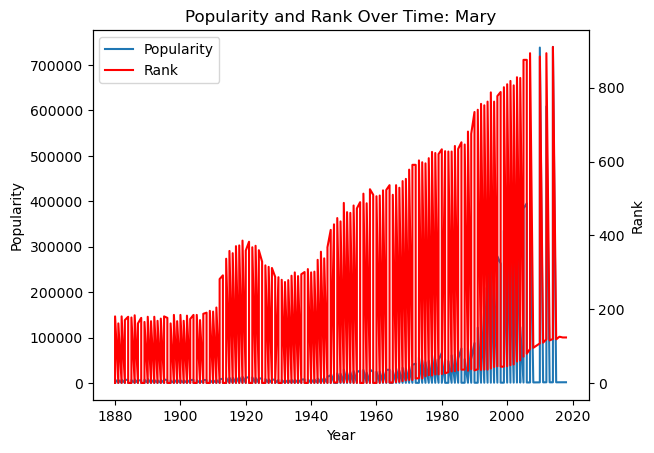

In [103]:
plot_names_popularity(['Mary'],baby_names)

# Why does a Name´s Popularity suddenly change? (Part 1)

17. __Add__ the additional columns __"Pop_lag1"__ (Popularity one year ago) and __"Pop_diff"__ (change in popularity from previous year to this year) to df.  

In [106]:
baby_names['Pop_lag1']  = (
    baby_names.sort_values(["Name", "Gender", "Year"])
      .groupby(["Name", "Gender"])["Popularity"]
      .shift(1)
)

In [109]:
baby_names['Pop_diff']=baby_names.Popularity.sub(baby_names.Pop_lag1)

In [110]:
baby_names[baby_names['Year']==2000].head()

,Year,Name,Gender,Count_x,Count_per_Year,Count_y,Popularity,Rank,Pop_lag1,Pop_diff
1332810,2000,Emily,F,25956,NaN,3778497,145.573162,1.0,139.147669,6.425493
1332811,2000,Hannah,F,23082,NaN,3778497,163.698856,2.0,170.365381,-6.666525
1332812,2000,Madison,F,19968,NaN,3778497,189.227614,3.0,204.555476,-15.327861
1332813,2000,Ashley,F,17997,NaN,3778497,209.951492,4.0,203.619321,6.332171
1332814,2000,Sarah,F,17702,NaN,3778497,213.450288,5.0,193.301926,20.148362


18. __Create__ df2 starting with the __year 1900__ (from 1900 till today).

In [111]:
df2 = baby_names[baby_names['Year']>1900]

19. __Filter__ df2 and find the __20 largest values__ in "Pop_diff" (get complete rows).

In [114]:
names = list(df2.nlargest(20,'Pop_diff')['Name'])

20. __Create__ the popularity/rank plot (see 15. and 16.) for the Names filtered in 19.

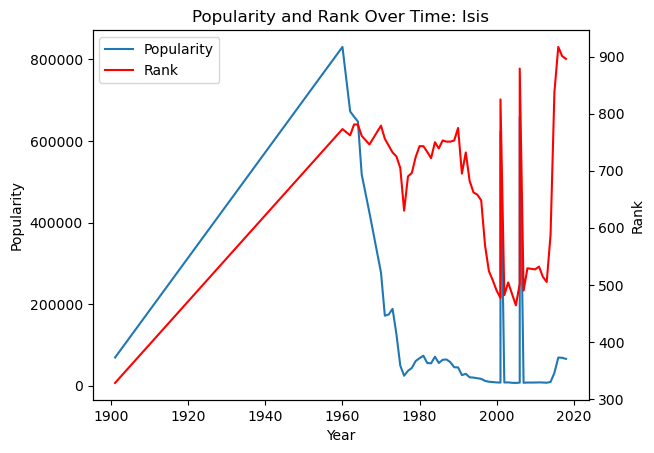

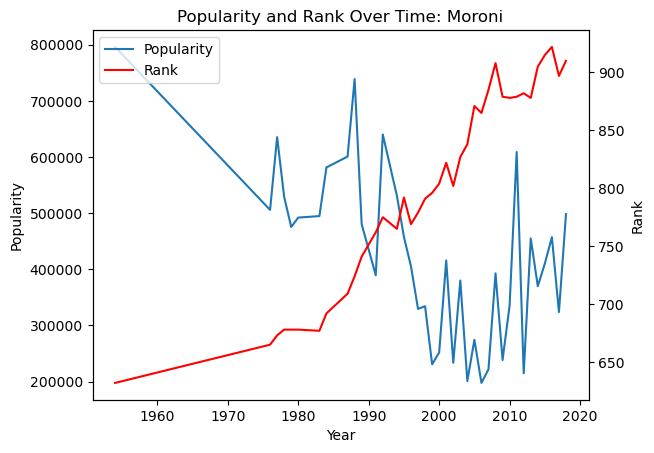

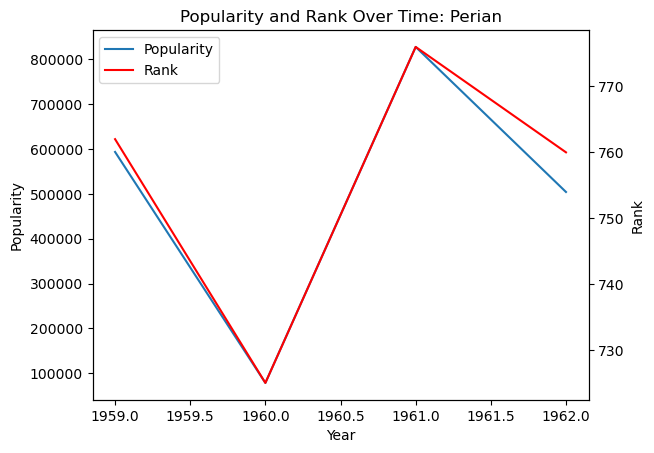

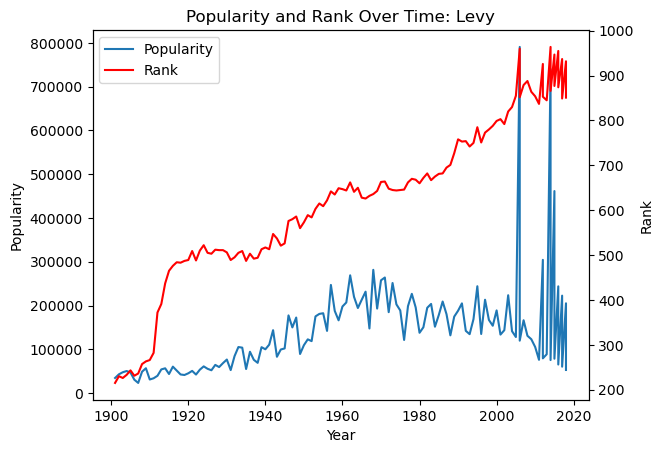

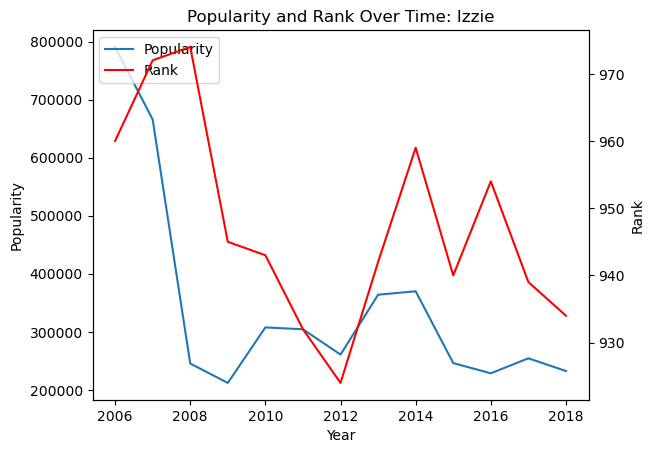

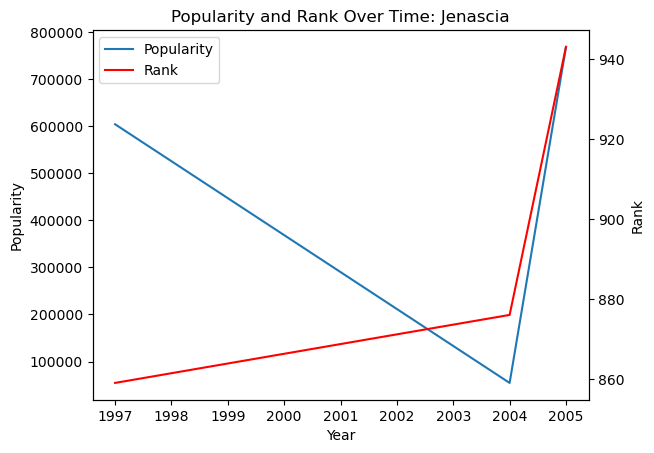

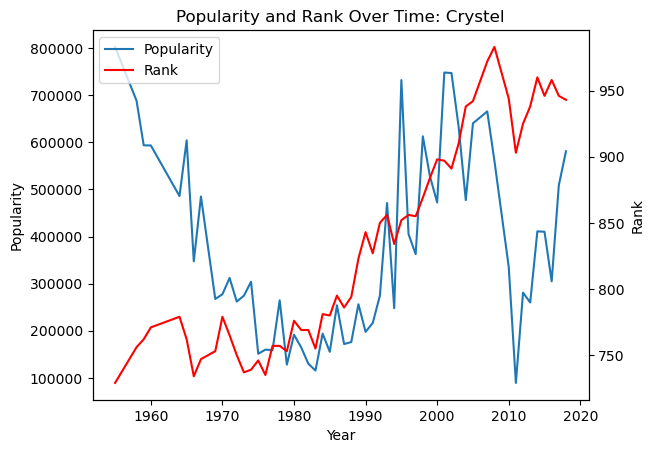

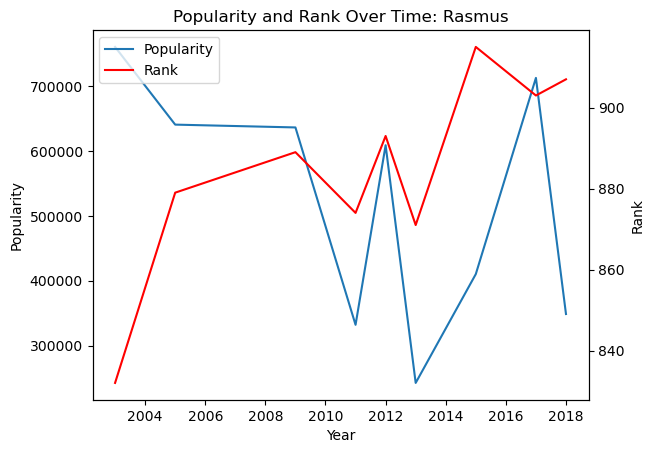

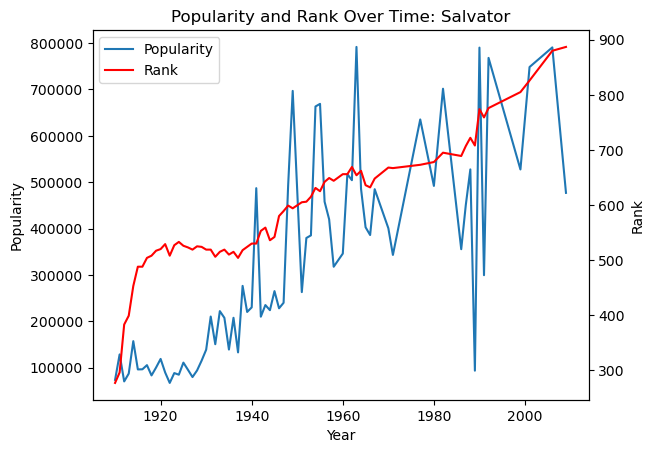

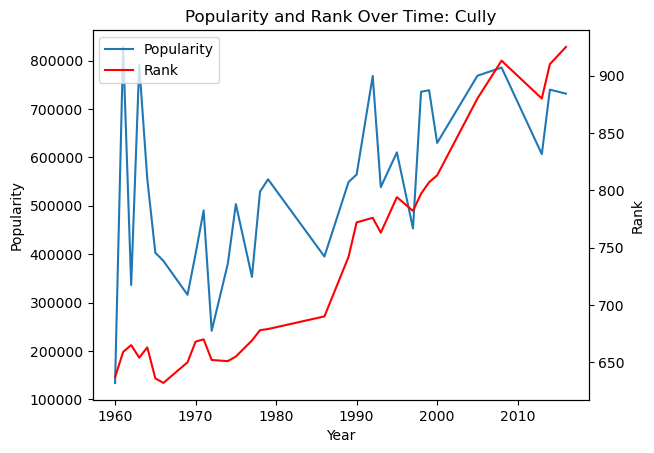

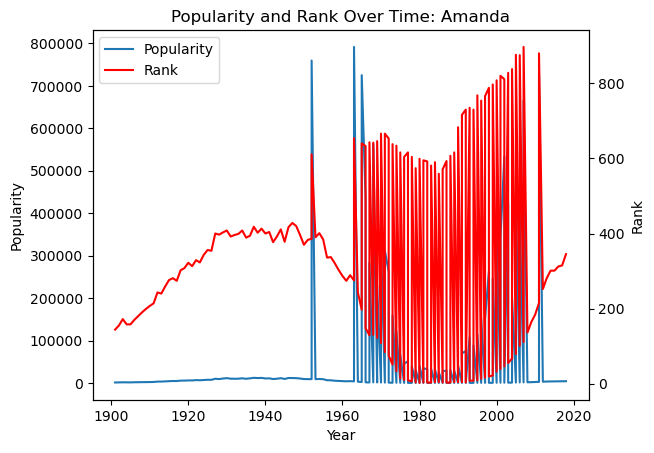

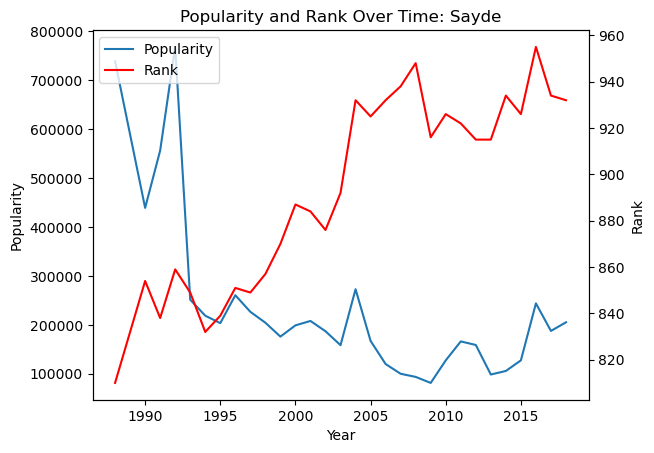

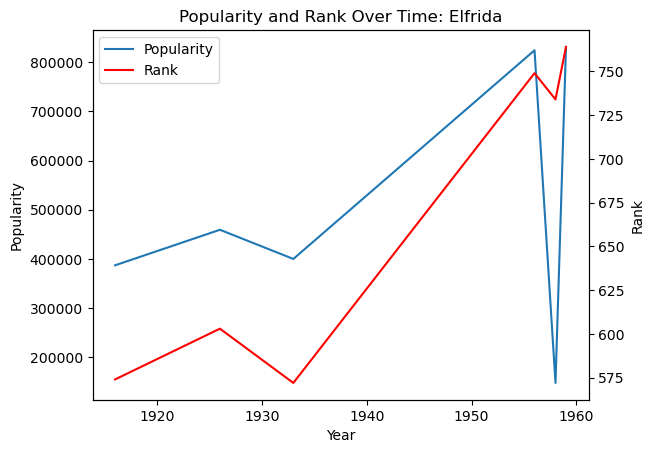

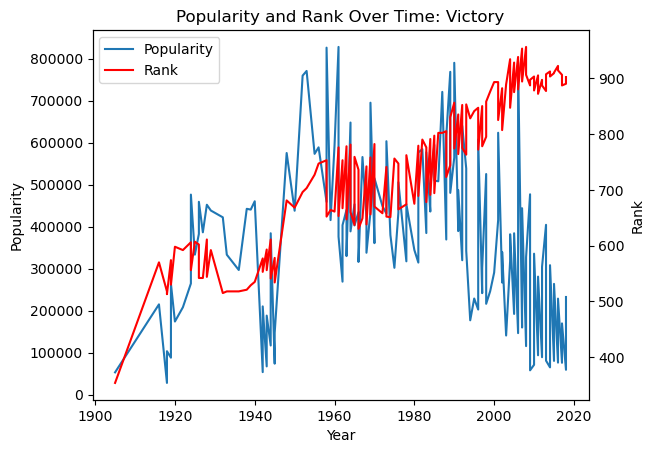

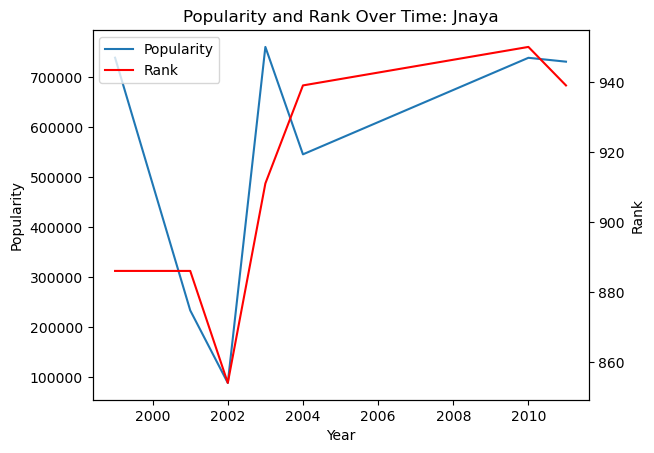

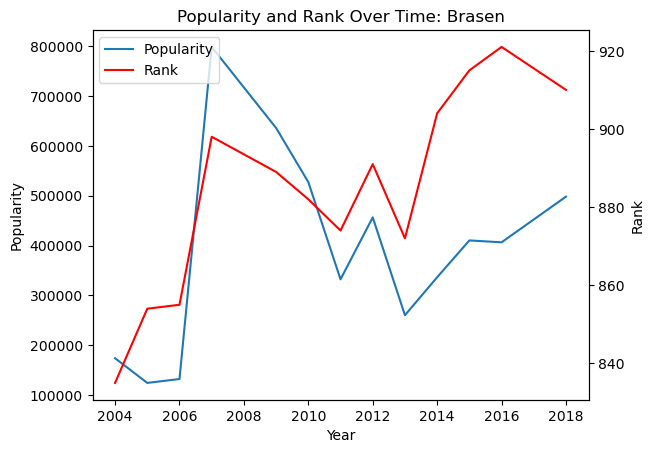

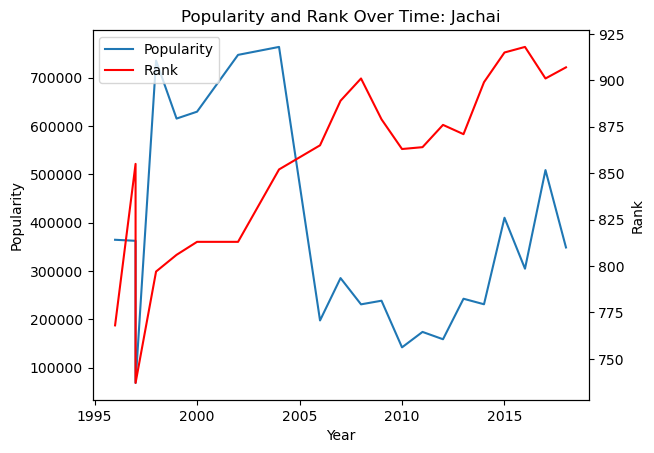

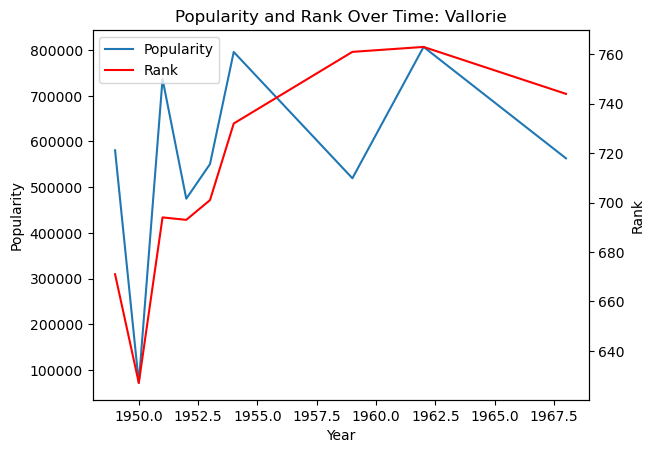

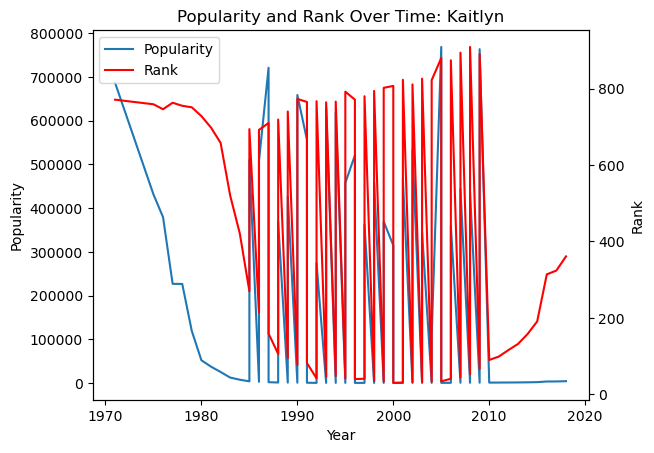

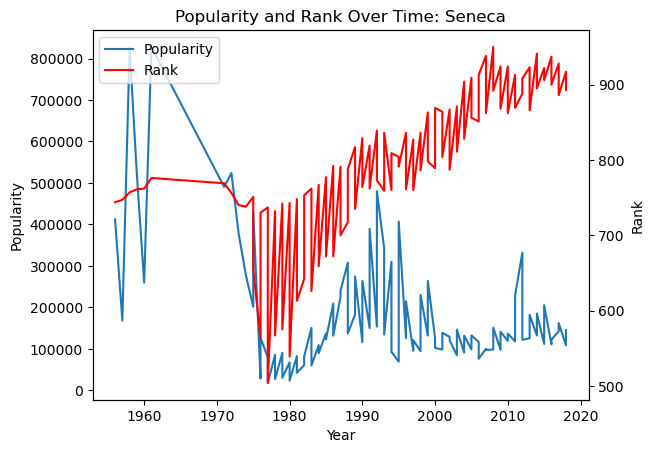

In [116]:
plot_names_popularity(names=names,df=df2)

21. __Search__ the Web for the Names __"Linda"__, __"Shirley"__ and __"Jason"__ and __find out__ why the popularity suddenly changed/spiked.

## Why does a Name´s Popularity suddenly change? (Part 2)

_No additional assignments on this. Watch the video for some more examples._

## Persistant vs. Spike-Fade Names

_No additional assignments on this. Watch the video for some more advanced examples._

## Most Popular Unisex Names

22. __Find__ the most popular __Unisex Names__ of all times. (Unisex names are names given to Boys and Girls).  

# +++++++++ See some Hints below +++++++++++++

# ++++++++++++++++ Hints++++++++++++++++++++

__Hints for 5. and 6.__<br>
Use most_pop().

__Hints for 7.__


In [ ]:
agg = df.groupby(...).agg(Total = (...), No_Year = (...), First_Year = (...), Last_Year = (...), Max_Count = (...))

Add Best_Year separately with a udf (tricky...)

__Hints for 10.__<br>
Aggregate agg further.

__Hints for 12.__<br>
Treat Instances of Unisex Names (eg. (Marie, F) and (Marie, M)) as different Names.

__Hints for 13.__<br>
Use groupby() and transform()

__Hints for 14.__<br>
Use groupby() and apply(lambda x: x.rank(ascending = False))

__Hints for 17.__<br>
shift() might help.

__Hints for 18.__<br>
difference between "Popularity" and "Pop_lag1".

__Hints for 19.__<br>
use nlargest()